# L2.1 — Excel/Google Sheets + ИИ

Демонстрация работы с данными в Python (аналог операций в Excel/Sheets).
Каждый блок показывает операцию, которую вы можете повторить в таблице.

## 1. Загрузка данных (аналог «Файл → Открыть»)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../shared/data/sales_data.csv')
print(f'Загружено: {len(df)} строк, {len(df.columns)} столбцов')
df.head()

Загружено: 47929 строк, 10 столбцов


,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue
0,10090,2024-01-01,C0127,Москва,Соцсети,Продукты,Чай,1,710.0,710.0
1,10046,2024-01-01,C0355,Челябинск,Реклама,Книги,Учебник,3,710.0,2130.0
2,10002,2024-01-01,C1992,Санкт-Петербург,Реклама,Дом и сад,Кашпо,1,4800.0,4800.0
3,10038,2024-01-01,C0176,Москва,Органика,Продукты,Чай,1,1140.0,1140.0
4,10059,2024-01-01,C0034,Челябинск,Органика,Красота,Маска,5,1930.0,9650.0


**Вывод:** Датасет содержит ~48K транзакций интернет-магазина за 2024 год.
В Excel это было бы 48 тысяч строк — уже на грани, Sheets начнёт тормозить.

## 2. Типичные проблемы в данных

In [2]:
# Пропуски (аналог пустых ячеек)
print('=== Пропуски ===')
print(df.isnull().sum())
print(f'\nПустых городов: {(df["city"] == "").sum()}')

# Дубликаты (аналог «Удалить дубликаты» в Data)
dupes = df.duplicated(subset=['order_id']).sum()
print(f'\nДубликатов по order_id: {dupes}')

=== Пропуски ===
order_id              0
date                  0
customer_id           0
city                478
channel               0
product_category      0
product               0
quantity              0
price                 0
revenue               0
dtype: int64

Пустых городов: 0

Дубликатов по order_id: 934


**Вывод:** ~478 пропусков в городе, ~934 дубликата. В Excel: Data → Remove Duplicates.

In [3]:
# Отрицательные цены (ошибки ввода)
neg_prices = df[df['price'] < 0]
print(f'Отрицательных цен: {len(neg_prices)}')
neg_prices.head()

Отрицательных цен: 240


,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue
26,10041,2024-01-01,C0382,Москва,Реклама,Одежда,Футболка,3,-9060.0,27180.0
111,10112,2024-01-01,C1353,Челябинск,Органика,Электроника,Наушники,1,-3450.0,3450.0
141,10270,2024-01-02,C1873,Москва,Соцсети,Электроника,Колонка,1,-1660.0,1660.0
211,10142,2024-01-02,C0648,Казань,Соцсети,Электроника,Наушники,2,-4160.0,8320.0
247,10254,2024-01-02,C1862,Санкт-Петербург,Реклама,Книги,Бизнес-книга,1,-1270.0,1270.0


**Вывод:** ~236 записей с отрицательной ценой — это ошибки, нужно исправить на abs().

## 3. Очистка данных

In [4]:
# Очистка за 3 шага
df_clean = df.copy()

# 1. Удаление дубликатов
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['order_id'])
print(f'Дубликаты: {before} → {len(df_clean)} (удалено {before - len(df_clean)})')

# 2. Заполнение пропусков
df_clean['city'] = df_clean['city'].replace('', np.nan).fillna('Не указан')
print(f'Пропуски city заполнены')

# 3. Исправление отрицательных цен
df_clean['price'] = df_clean['price'].abs()
df_clean['revenue'] = df_clean['revenue'].abs()
print(f'Отрицательные цены исправлены')

Дубликаты: 47929 → 46995 (удалено 934)
Пропуски city заполнены
Отрицательные цены исправлены


## 4. Формулы (аналог Excel-формул)

In [6]:
# AVERAGE — среднее (аналог =AVERAGE(J:J))
print(f'Средний чек: {df_clean["revenue"].mean():,.0f} руб.')

# MEDIAN — медиана
print(f'Медиана чека: {df_clean["revenue"].median():,.0f} руб.')

# COUNTIF — количество по условию (аналог =COUNTIF(D:D, "Москва"))
moscow_count = len(df_clean[df_clean['city'] == 'Москва'])
print(f'Заказов из Москвы: {moscow_count}')

# SUMIF — сумма по условию
moscow_revenue = df_clean[df_clean['city'] == 'Москва']['revenue'].sum()
print(f'Выручка Москвы: {moscow_revenue:,.0f} руб.')

Средний чек: 6,320 руб.
Медиана чека: 4,150 руб.
Заказов из Москвы: 16215
Выручка Москвы: 103,103,620 руб.


In [7]:
# AVERAGEIFS — среднее с несколькими условиями
# Аналог: =AVERAGEIFS(J:J, D:D, "Москва", E:E, "Органика")
mask = (df_clean['city'] == 'Москва') & (df_clean['channel'] == 'Органика')
avg_moscow_organic = df_clean[mask]['revenue'].mean()
print(f'Средний чек Москва + Органика: {avg_moscow_organic:,.0f} руб.')

Средний чек Москва + Органика: 6,479 руб.


## 5. Сводная таблица (аналог Insert → Pivot Table)

In [8]:
# Сводная: выручка по городам × каналам
pivot = df_clean.pivot_table(
    values='revenue',
    index='city',
    columns='channel',
    aggfunc='sum',
    fill_value=0,
    margins=True  # добавляет строку/столбец «Итого»
).round(0)

# Топ-5 городов
pivot.sort_values('All', ascending=False).head(6)

channel,Email,Органика,Реклама,Реферал,Соцсети,All
city,,,,,,
All,46131690.0,89108790.0,103141510.0,24804270.0,33811600.0,296997860.0
Москва,15892870.0,31423600.0,35944060.0,8410910.0,11432180.0,103103620.0
Санкт-Петербург,7676890.0,14977250.0,16588480.0,3881450.0,5098810.0,48222880.0
Казань,4087300.0,7926630.0,8657230.0,2316780.0,3165700.0,26153640.0
Новосибирск,3290910.0,6928220.0,7438370.0,2006800.0,2760060.0,22424360.0
Екатеринбург,2268410.0,4841520.0,5700650.0,1221030.0,2184920.0,16216530.0


**Вывод:** Москва — 35% выручки, рекламный канал лидирует во всех городах.

## 6. Условное форматирование + визуализация

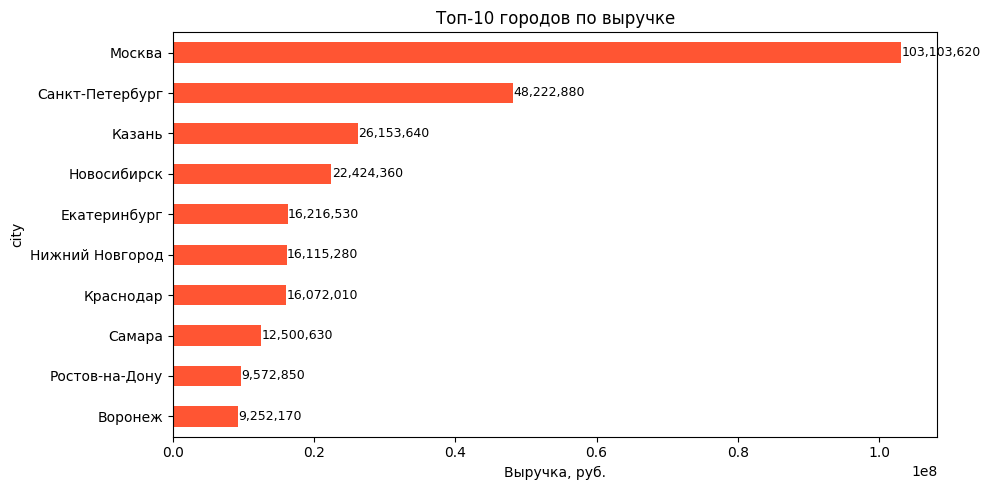

In [5]:
import matplotlib.pyplot as plt

# Топ-10 городов (аналог сводной диаграммы)
city_rev = df_clean.groupby('city')['revenue'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 5))
city_rev.plot(kind='barh', color='#ff5533', ax=ax)
ax.set_xlabel('Выручка, руб.')
ax.set_title('Топ-10 городов по выручке')
for i, v in enumerate(city_rev):
    ax.text(v + 50000, i, f'{v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

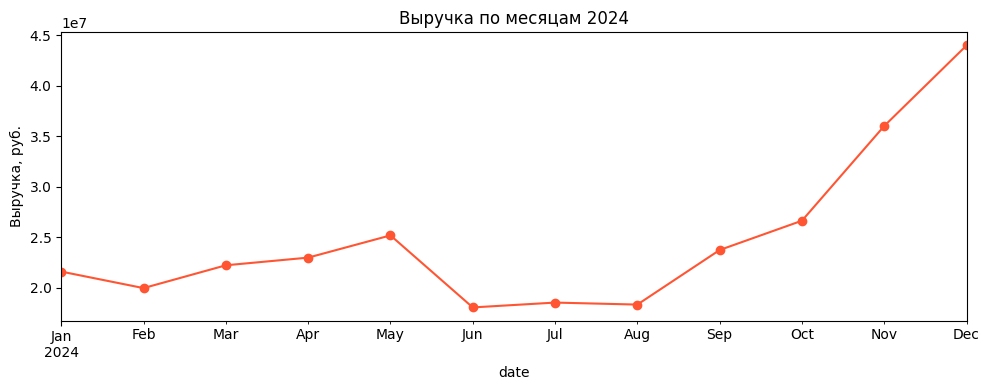

In [10]:
# Тренд по месяцам (аналог SPARKLINE в Sheets)
df_clean['date'] = pd.to_datetime(df_clean['date'])
monthly = df_clean.set_index('date').resample('ME')['revenue'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(marker='o', color='#ff5533', ax=ax)
ax.set_ylabel('Выручка, руб.')
ax.set_title('Выручка по месяцам 2024')
plt.tight_layout()
plt.show()

**Вывод:** Чёткая сезонность — пик в ноябре-декабре (+50-80%), спад летом.

## 7. VLOOKUP аналог (merge)

In [11]:
# Создадим справочник категорий (как отдельный лист в Excel)
category_info = pd.DataFrame({
    'product_category': ['Электроника', 'Одежда', 'Книги', 'Дом и сад', 'Спорт', 'Красота', 'Продукты'],
    'margin_pct': [25, 40, 50, 35, 30, 55, 20],
    'manager': ['Иванов', 'Петрова', 'Сидоров', 'Петрова', 'Козлов', 'Петрова', 'Сидоров']
})

# VLOOKUP = merge (объединение таблиц)
df_with_info = df_clean.merge(category_info, on='product_category', how='left')
df_with_info[['order_id', 'product_category', 'revenue', 'margin_pct', 'manager']].head(10)

,order_id,product_category,revenue,margin_pct,manager
0,10090,Продукты,710.0,20,Сидоров
1,10046,Книги,2130.0,50,Сидоров
2,10002,Дом и сад,4800.0,35,Петрова
3,10038,Продукты,1140.0,20,Сидоров
4,10059,Красота,9650.0,55,Петрова
5,10020,Книги,1790.0,50,Сидоров
6,10019,Красота,3850.0,55,Петрова
7,10021,Продукты,430.0,20,Сидоров
8,10051,Одежда,9490.0,40,Петрова
9,10023,Электроника,2720.0,25,Иванов


**Вывод:** merge() — это VLOOKUP, но мощнее: работает в обе стороны, с любыми ключами.
В Sheets: =VLOOKUP(F2, CategoryInfo!A:C, 2, FALSE)

## Итоги

| Операция Excel/Sheets | Аналог Python/pandas |
|---|---|
| Открыть файл | `pd.read_csv()` |
| Удалить дубликаты | `df.drop_duplicates()` |
| AVERAGE, SUM, COUNT | `df['col'].mean()`, `.sum()`, `.count()` |
| AVERAGEIFS | `df[mask]['col'].mean()` |
| Сводная таблица | `df.pivot_table()` |
| VLOOKUP | `pd.merge()` |
| Условное форматирование | `matplotlib` + цветовые шкалы |
| Диаграмма | `df.plot()` |